In [2]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
df=pd.read_csv("class_ipl_22-26_dataset.csv")
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."


In [2]:
df.shape

(367, 25)

#which ipl team scored highest average runs

mean: 185.0708446866485
median: 187.0
mode: 187.0
min: 25
max: 287
std: 36.516264735979796


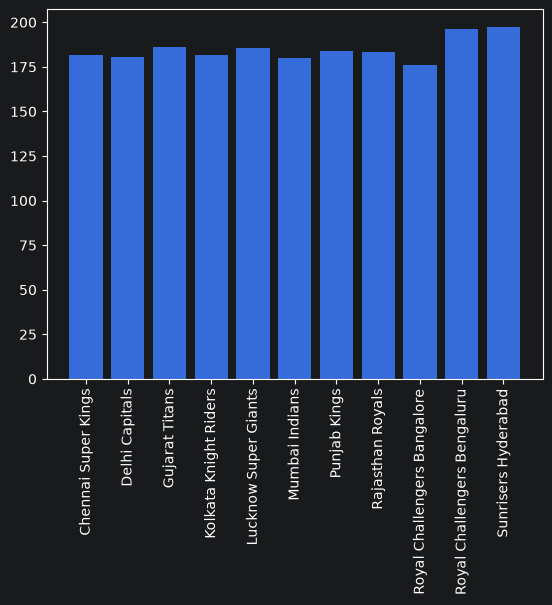

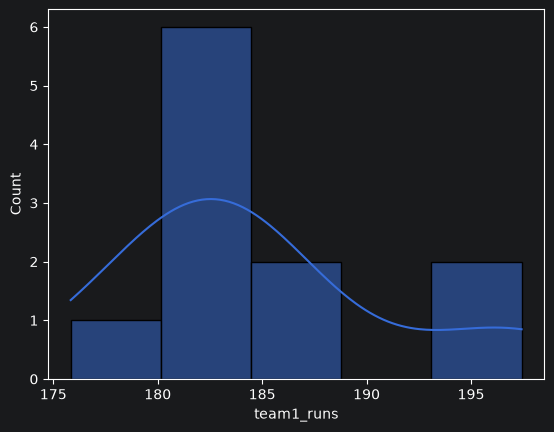

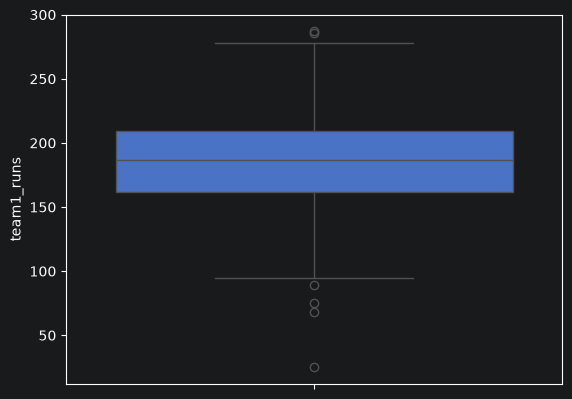

In [27]:
mean=df["team1_runs"].mean()
med=df["team1_runs"].median()
mod=df["team1_runs"].mode()
min=df["team1_runs"].min()
max=df["team1_runs"].max()
std=df["team1_runs"].std()
print("mean:",mean)
print("median:",med)
print("mode:",med)
print("min:",min)
print("max:",max)
print("std:",std)
avg_runs= df.groupby("team1")["team1_runs"].mean()
plt.bar(avg_runs.index,avg_runs.values)
plt.xticks(rotation=90)
plt.show()
sb.histplot(avg_runs,kde=True)
plt.show()
sb.boxplot(df["team1_runs"])
plt.show()

#which city hosted the most ipl matches

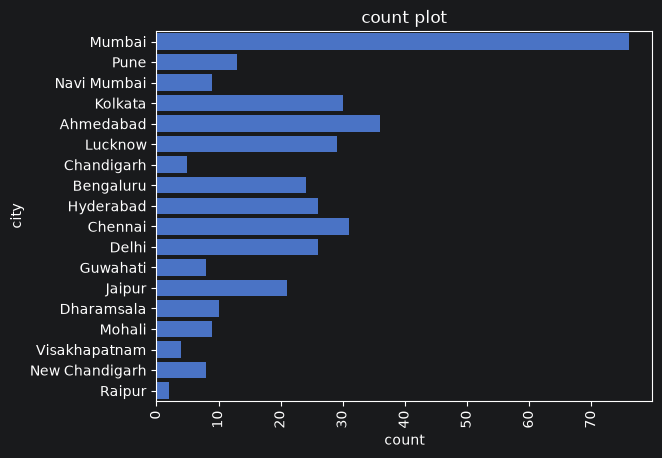

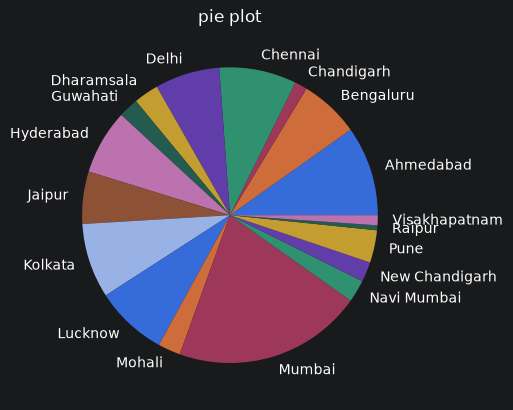

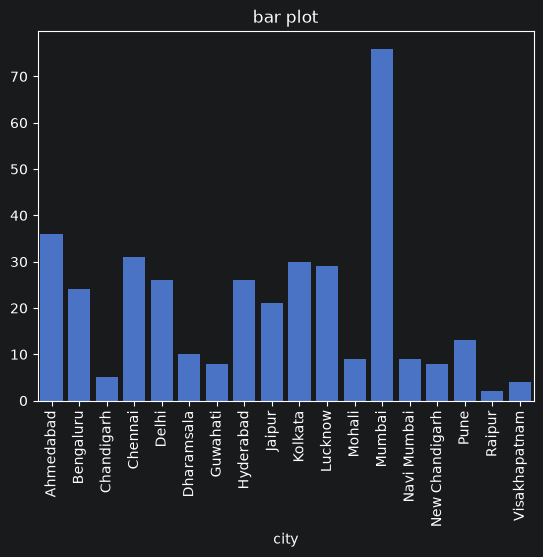

In [47]:
matches=df.groupby("city")["city"].value_counts()
plt.title("count plot")
sb.countplot(df["city"]).tick_params(labelrotation=90,axis="x")
plt.show()
plt.title("pie plot")
plt.pie(matches.values,labels=matches.index)
plt.show()
plt.title("bar plot")
sb.barplot(x=matches.index,y=matches.values).tick_params(labelrotation=90,axis="x")
plt.show()

#which toss decision is more comman

mode:  0    field
Name: toss_decision, dtype: str
toss_decision
bat       82
field    285
Name: count, dtype: int64
367
bat percent:  22.3433242506812
field percent:  77.65667574931881


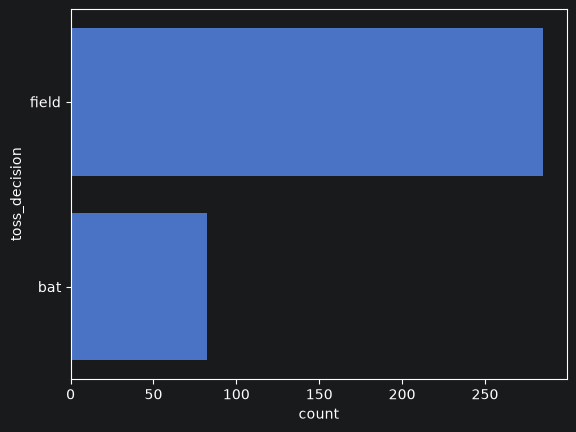

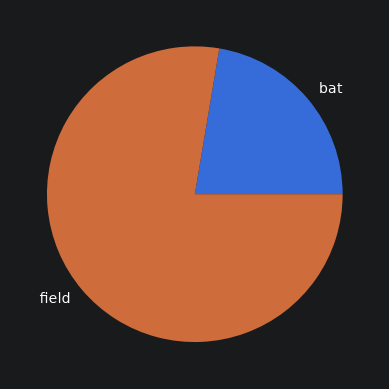

In [65]:
print("mode: ",df["toss_decision"].mode())
toss=df.groupby("toss_decision")["toss_decision"].value_counts()
total=df["toss_decision"].count()
print(toss)
print(total)
percent=(toss.values/total)*100
print("bat percent: ",percent[0])
print("field percent: ",percent[1])
sb.countplot(df["toss_decision"])
plt.show()
plt.pie(toss.values,labels=toss.index)
plt.show()

#does winning toss help in winning match

toss_win_match_win
False    186
True     181
Name: count, dtype: int64


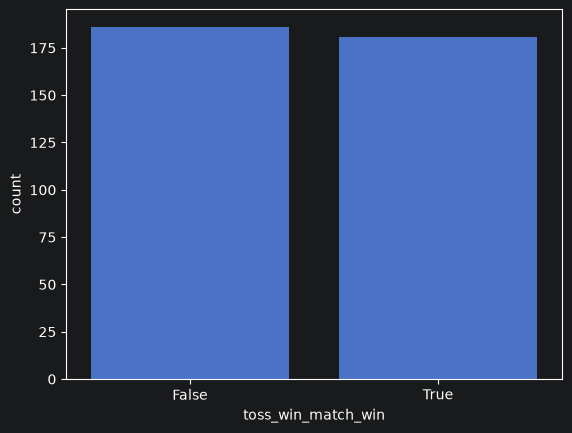

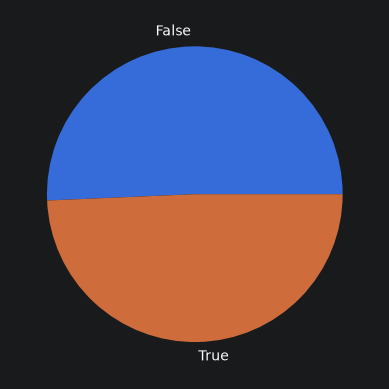

In [83]:
df1=df
df1.head()
df1["toss_win_match_win"]=df1["toss_winner"]==df1["winner"]
df1.head()
count=df1.groupby("toss_win_match_win")["toss_win_match_win"].value_counts()
print(count)
sb.countplot(x=df1["toss_win_match_win"])
plt.show()
plt.pie(count.values,labels=count.index)
plt.show()

#relationship between team1 runs and team2 runs

                      season  team1_runs  team1_wickets  team2_runs  \
season              1.000000    0.195486       0.011492    0.160540   
team1_runs          0.195486    1.000000      -0.516325    0.701668   
team1_wickets       0.011492   -0.516325       1.000000   -0.296213   
team2_runs          0.160540    0.701668      -0.296213    1.000000   
team2_wickets      -0.081331    0.388278      -0.195583    0.011882   
win_by_runs         0.021167    0.415006      -0.223085   -0.241028   
win_by_wickets      0.071676   -0.395757       0.294736    0.074071   
overs_limit              NaN         NaN            NaN         NaN   
toss_win_match_win  0.042220   -0.281995       0.183545    0.017939   

                    team2_wickets  win_by_runs  win_by_wickets  overs_limit  \
season                  -0.081331     0.021167        0.071676          NaN   
team1_runs               0.388278     0.415006       -0.395757          NaN   
team1_wickets           -0.195583    -0.223085      

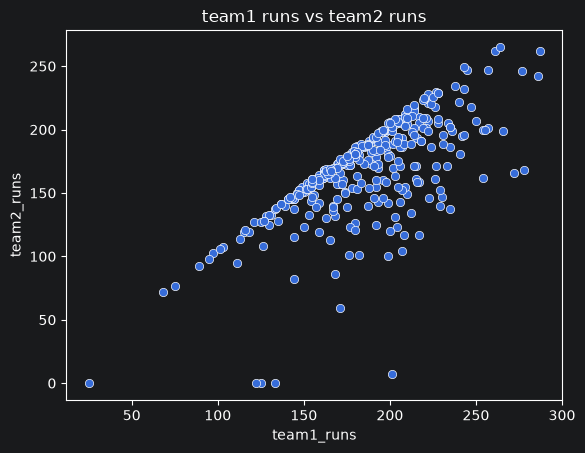

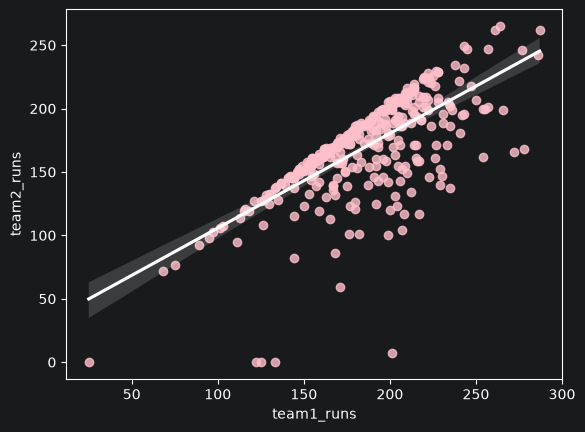

In [102]:
correlation=df1.corr(numeric_only=True)
print(correlation)
plt.title("team1 runs vs team2 runs")
sb.scatterplot(data=df1,x="team1_runs",y="team2_runs")
plt.show()
sb.regplot(data=df1,x=df1["team1_runs"],y=df1["team2_runs"],color="pink",line_kws={'color':'white'})
plt.show()

date                   0
season                 0
city                   6
venue                  0
team1                  0
team2                  0
toss_winner            0
toss_decision          0
team1_runs            11
team1_wickets          0
team2_runs             0
team2_wickets          0
winner                 7
result_type            0
win_by_runs            0
win_by_wickets         0
player_of_match        5
match_referee          0
umpire1                0
umpire2                0
tv_umpire              0
reserve_umpire         0
overs_limit            0
team1_players          0
team2_players          0
toss_win_match_win     0
dtype: int64


<Axes: >

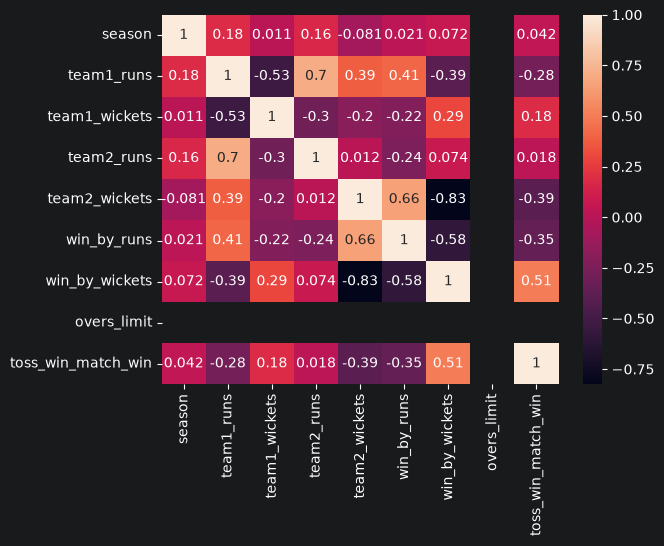

In [110]:
df1=df
df1.loc[10:20,"team1_runs"]=None
df1.loc[30:35,"city"]=None
print(df1.isnull().sum())
cor=df1.corr(numeric_only=True)
sb.heatmap(cor,annot=True)

11


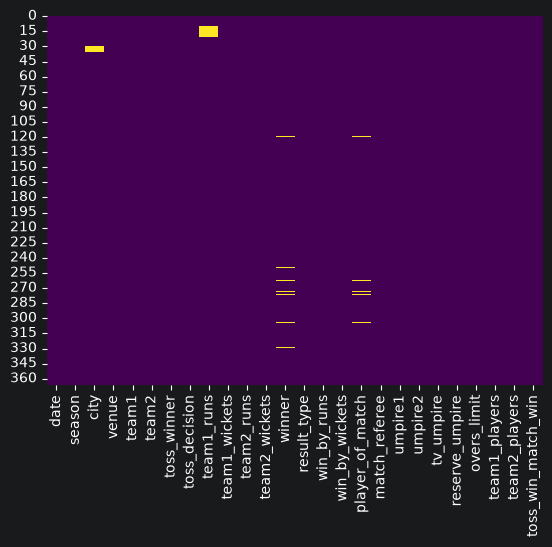

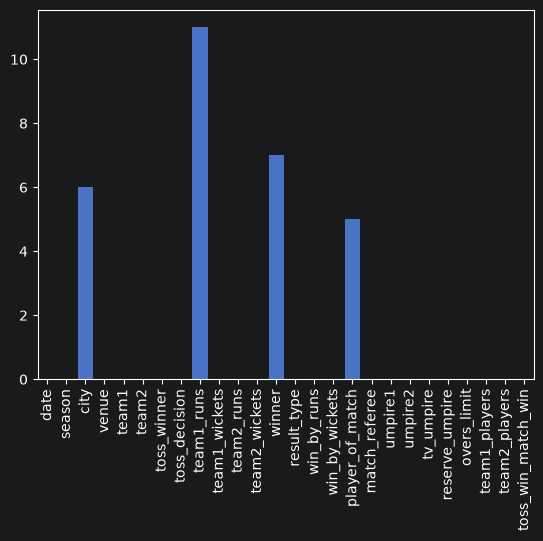

In [128]:
df1=df
missing=df1.isnull().sum().sum()
total=df1.shape[0]
missing_percent=(missing/total)*100
print(df1.isnull().sum().max())
sb.heatmap(df1.isnull(),cbar=False,cmap="viridis")
plt.show()
sb.barplot(df1.isnull().sum()).tick_params(labelrotation=90,axis="x")
plt.show()

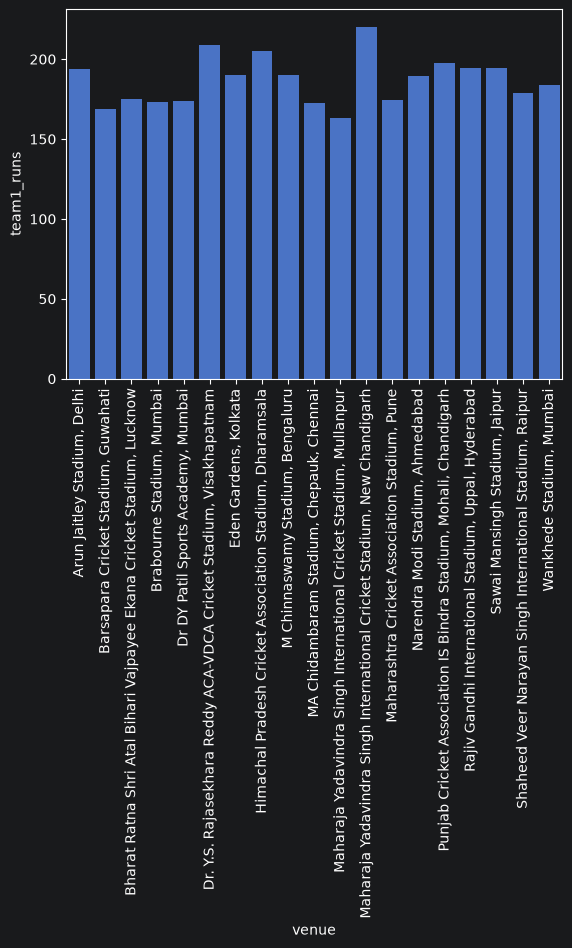

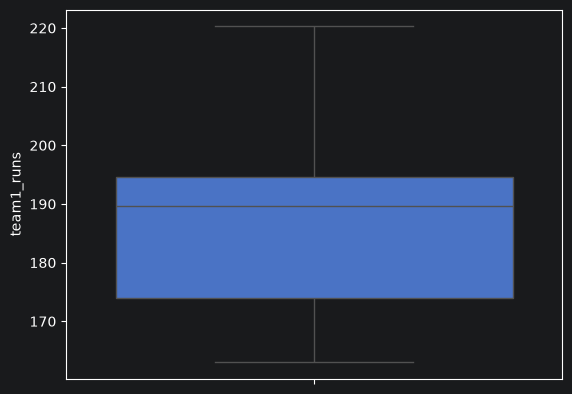

In [133]:
df1=df
avg_runs_by_venue=df1.groupby("venue")["team1_runs"].mean()
sb.barplot(avg_runs_by_venue).tick_params(axis="x",labelrotation=90)
plt.show()
sb.boxplot(avg_runs_by_venue)
plt.show()

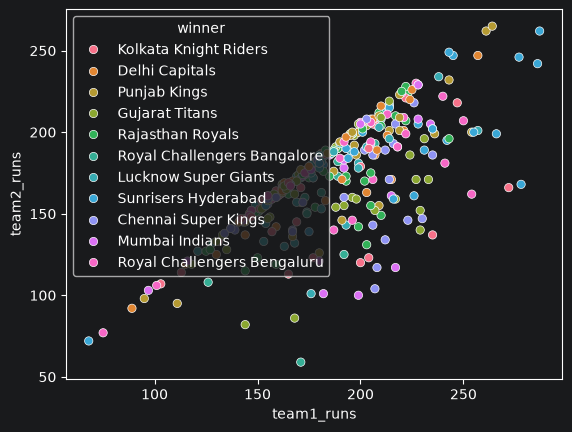

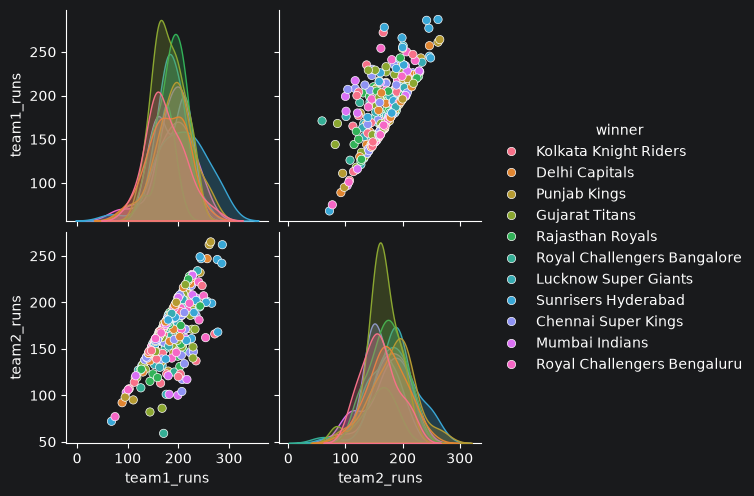

In [8]:
df1=df
cols=['team1_runs','team2_runs','toss_decision','winner']
df2=df1[cols]
sb.scatterplot(data=df2,x="team1_runs",y="team2_runs",hue='winner')
plt.show()
sb.pairplot(data=df2,hue='winner')
plt.show()

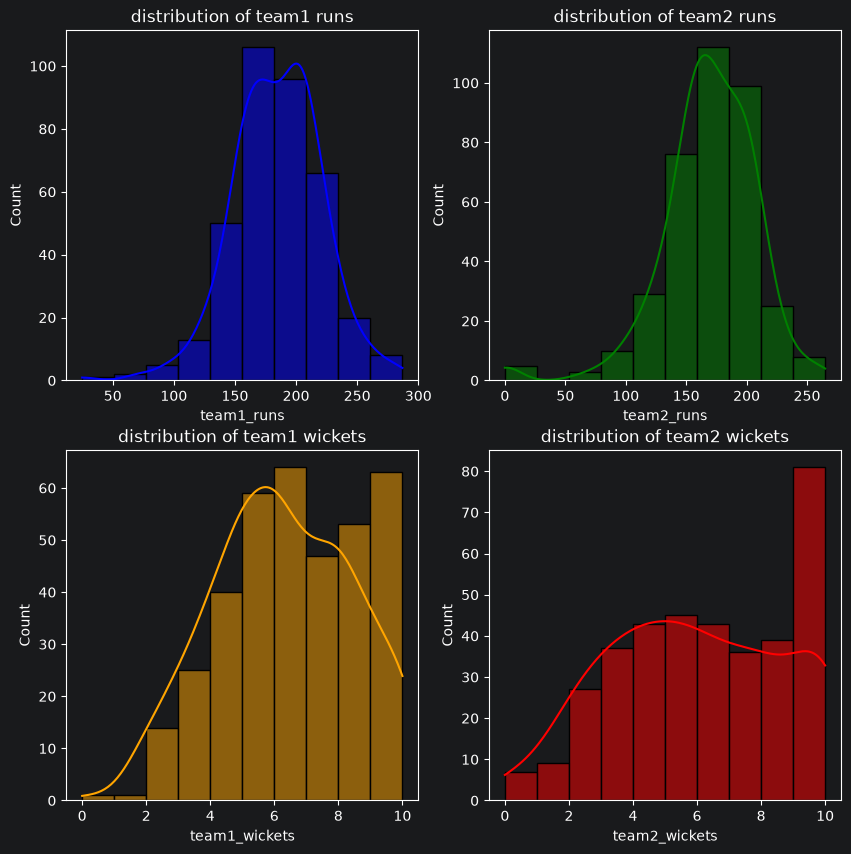

In [13]:
df1=df
fig,axes=plt.subplots(2,2,figsize=(10,10))
sb.histplot(data=df1,x='team1_runs',bins=10,kde=True,ax=axes[0,0],color='blue').set_title("distribution of team1 runs")
sb.histplot(data=df1,x='team2_runs',bins=10,kde=True,ax=axes[0,1],color='green').set_title("distribution of team2 runs")
sb.histplot(data=df1,x='team1_wickets',bins=10,kde=True,ax=axes[1,0],color='orange').set_title("distribution of team1 wickets")
sb.histplot(data=df1,x='team2_wickets',bins=10,kde=True,ax=axes[1,1],color='red').set_title("distribution of team2 wickets")
#sb.histplot(data=df1,x='over',bins=10,kde=True,ax=axes[1,1],color='purple')
#axes[1,1].set_title("distribution of overs")
plt.show()

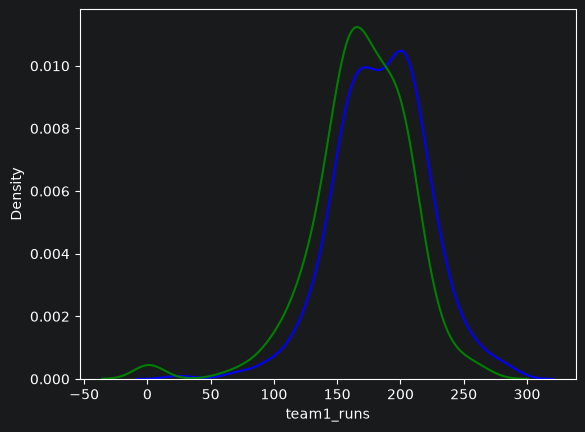

In [14]:
sb.kdeplot(data=df1,x='team1_runs',color='blue')
sb.kdeplot(data=df1,x='team2_runs',color='green')
plt.show()

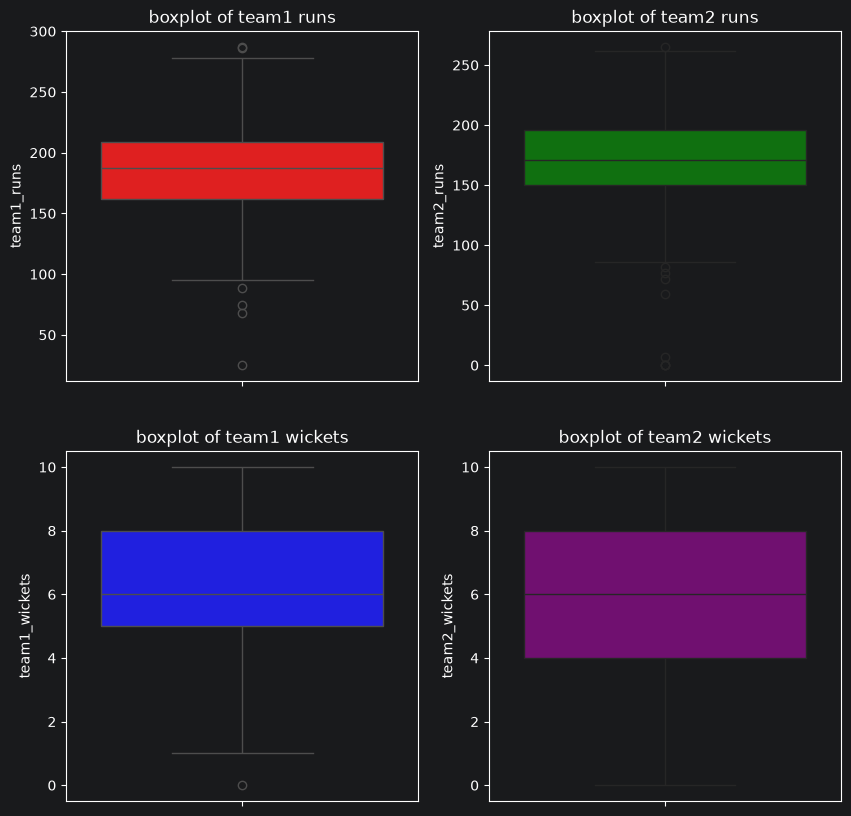

In [20]:
fig,axes=plt.subplots(2,2,figsize=(10,10))
sb.boxplot(df1['team1_runs'],ax=axes[0,0],color='red').set_title("boxplot of team1 runs")
sb.boxplot(df1['team2_runs'],ax=axes[0,1],color='green').set_title("boxplot of team2 runs")
sb.boxplot(df1['team1_wickets'],ax=axes[1,0],color='blue').set_title("boxplot of team1 wickets")
sb.boxplot(df1['team2_wickets'],ax=axes[1,1],color='purple').set_title("boxplot of team2 wickets")
plt.show()

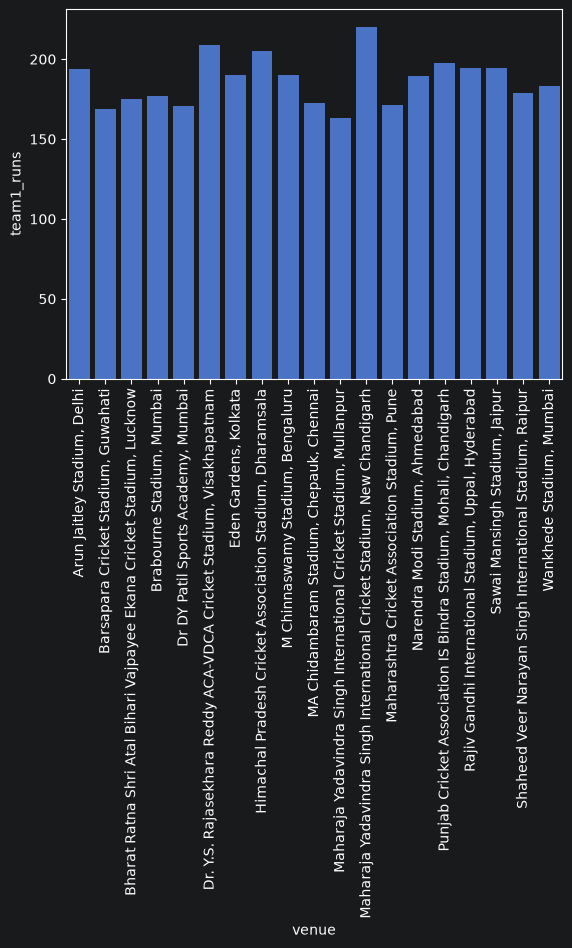

In [22]:
avg_runs_by_venue=df1.groupby("venue")["team1_runs"].mean()
sb.barplot(avg_runs_by_venue).tick_params(rotation=90,axis="x")